# Actividad PCA

In [8]:
from pathlib import Path
import pandas as pd

# Importar dataset
DATA_PATH = Path.cwd() / "auto-mpg.csv"

data = pd.read_csv(DATA_PATH)
df = pd.DataFrame(data)

print("Sample data:")
df.head(5)

Sample data:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [9]:
#non_numeric_hp: df[~df['horsepower'].str.replace('.', '',1).str.isnumeric()]['horsepower'].unique()
non_numeric_hp = df.loc[
    pd.to_numeric(df['horsepower'], errors='coerce').isna(),
    'horsepower'
].unique()

print("Non-numeric horsepower values:", non_numeric_hp)

Non-numeric horsepower values: ['?']


In [24]:
import numpy as np

df['horsepower'].replace('?', np.nan, inplace=True)

df['horsepower'] = pd.to_numeric(df['horsepower'])

df.isnull().sum()

/var/folders/kr/zlpqlpw96cj2wmtlnvjrfzc40000gn/T/ipykernel_5439/412889578.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].replace('?', np.nan, inplace=True)


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [26]:
mean_hp = df['horsepower'].mean()
df['horsepower'] = df['horsepower'].fillna(mean_hp)

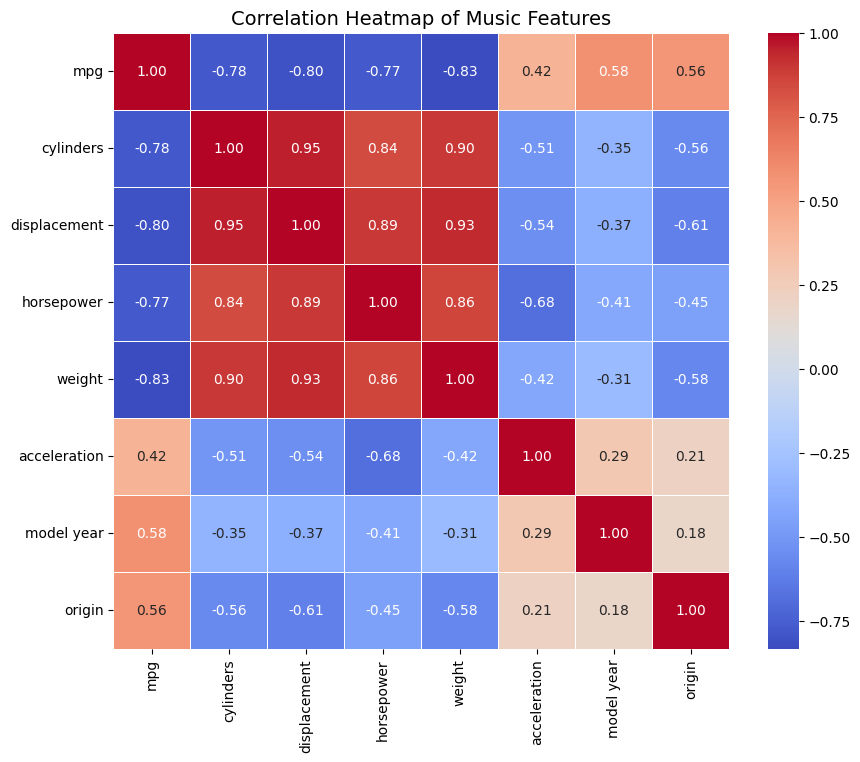

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=0.5)

plt.title('Correlation Heatmap of Music Features', fontsize = 14)

plt.show()

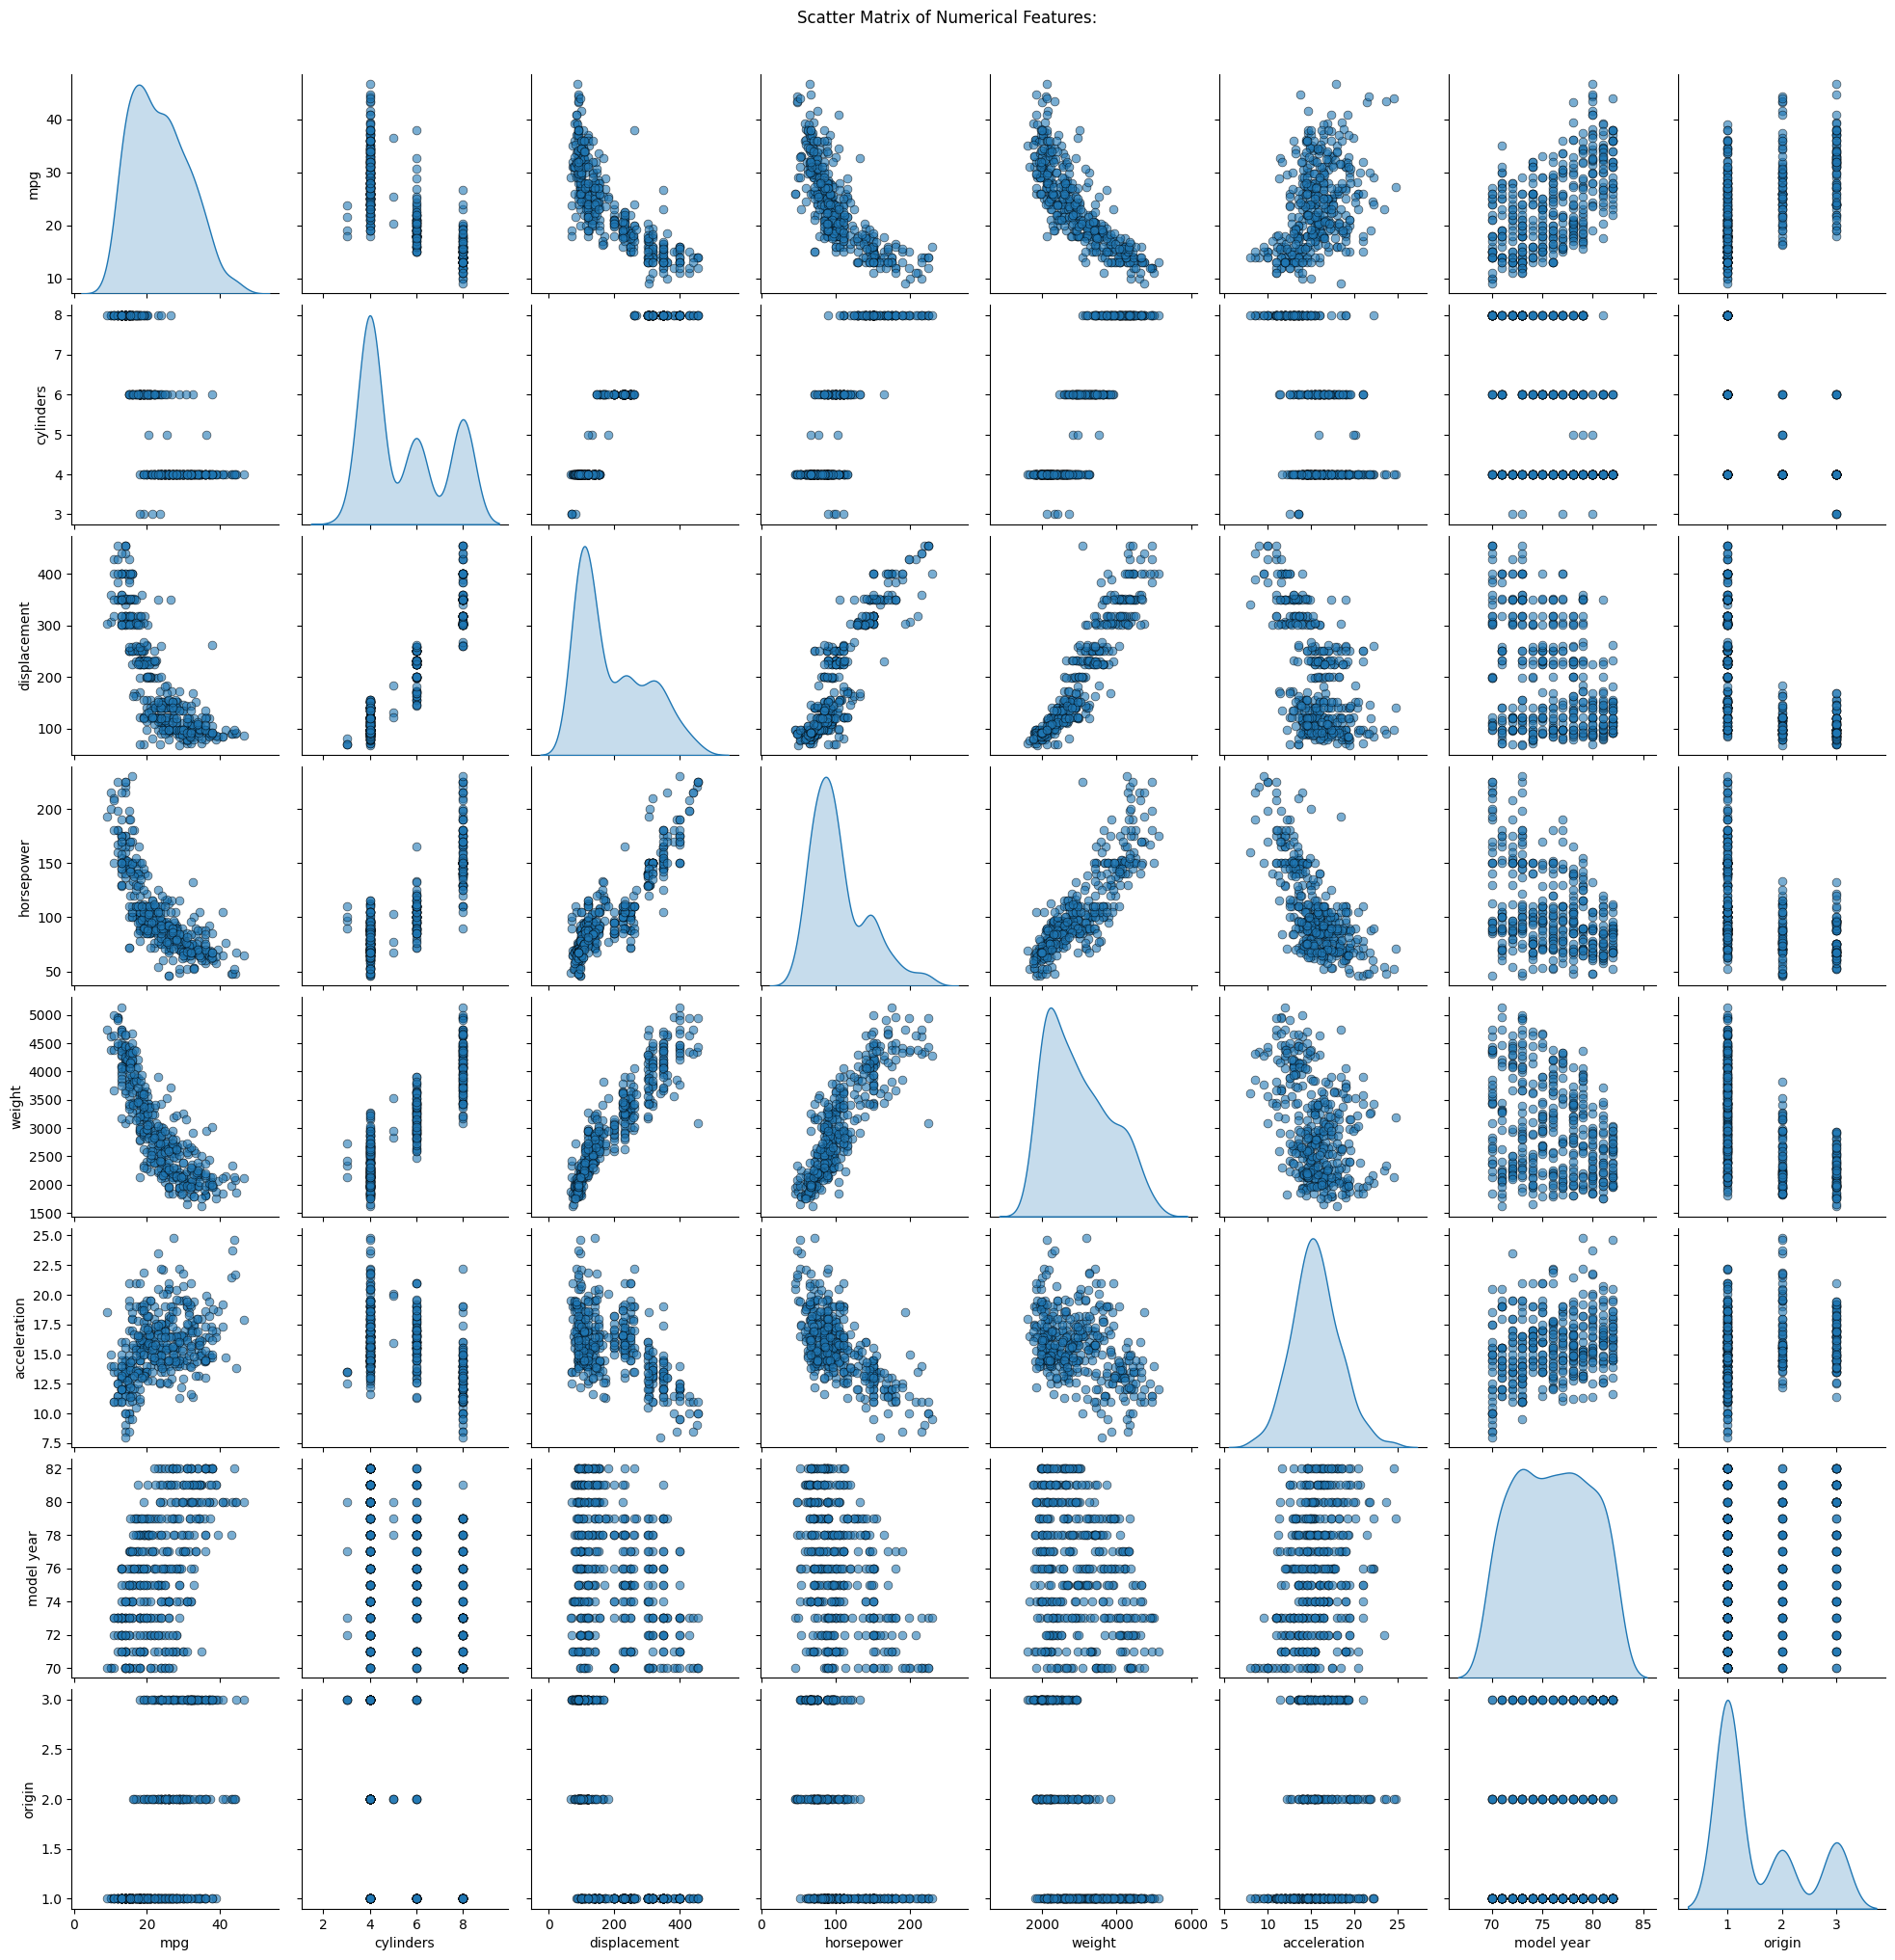

In [28]:
import seaborn as sns 
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.pairplot(numeric_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40, 'edgecolor':'k'})

plt.suptitle("Scatter Matrix of Numerical Features:", y=1.02)
plt.show()

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df.drop(columns=['car name', 'origin'])

X = add_constant(X)

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [
	variance_inflation_factor(X.values, i)
	for i in range(X.shape[1])
]
vif



,Feature,VIF
0,const,1.000000
1,mpg,5.227504
2,cylinders,10.604849
3,displacement,19.765922
4,horsepower,8.644376
5,weight,13.429119
6,acceleration,2.510462
7,model year,1.910226
